## Non-contiguous gridded data

This example demonstrates how to plot non-contiguous gridded data. Note that this example makes use of [Polytope](https://polytope.readthedocs.io/en/latest/) to extract country-masked regions.

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

from earthkit.geo.cartography import country_polygons

countries = ["Germany", "United Kingdom", "Italy"]

shapes = country_polygons(countries, resolution=50e6)

request = {
    "class": "od",
    "stream": "oper",
    "type": "fc",
    "levtype": "sfc",
    "date": 0,
    "time": 0,
    "expver": 1,
    "param": [167, 151],
    "step": 0,
    "feature": {
        "type": "polygon",
        "shape": shapes,
    },
}

ds = ekd.from_source(
    "polytope", "ecmwf-mars", request, stream=False, address="polytope.ecmwf.int"
).to_xarray()

2026-06-23 15:19:44 - INFO - Key read from /Users/mavj/.polytopeapirc
2026-06-23 15:19:44 - INFO - Sending request...
{'request': 'class: od\n'
            'date: 0\n'
            'expver: 1\n'
            'feature:\n'
            '  shape:\n'
            '  - - - 53.172412109374996\n'
            '      - -4.278613281249989\n'
            '    - - 53.1341796875\n'
            '      - -4.373046875\n'
            '    - - 53.178027343749996\n'
            '      - -4.418847656249994\n'
            '    - - 53.1763671875\n'
            '      - -4.471972656249989\n'
            '    - - 53.26044921875\n'
            '      - -4.55322265625\n'
            '    - - 53.386474609375\n'
            '      - -4.56787109375\n'
            '    - - 53.419287109375\n'
            '      - -4.461718749999989\n'
            '    - - 53.417236328125\n'
            '      - -4.315087890624994\n'
            '    - - 53.321435546875\n'
            '      - -4.19677734375\n'
            '    - - 53.30

bccc48be-c4a5-4023-914e-10fc7e5fa327.covjson:   0%|          | 0.00/709k [00:00<?, ?B/s]

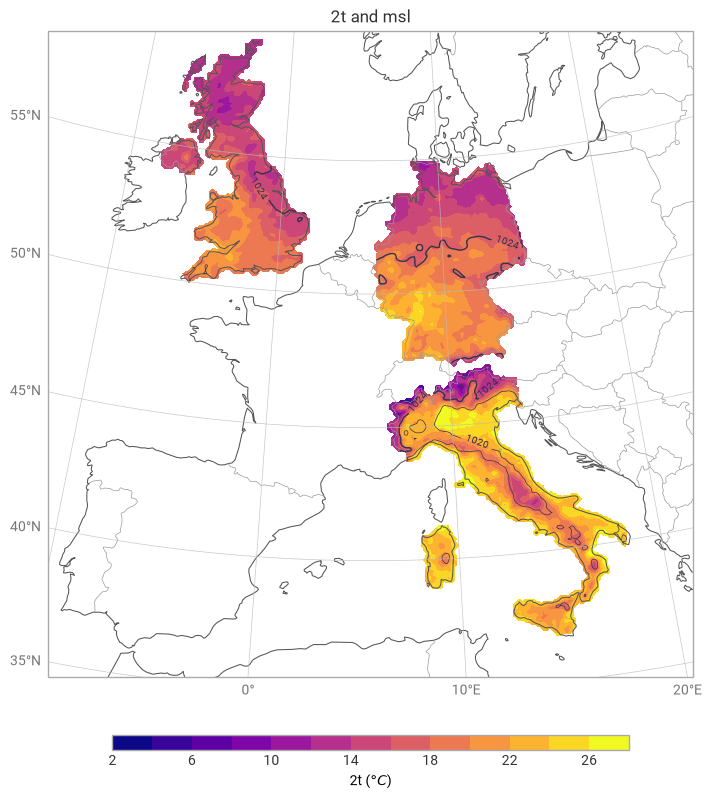

In [2]:
chart = ekp.Map(domain=countries)
chart.contourf(ds["2t"], units="celsius")
chart.contour(ds["msl"], units="hPa", style="auto")
chart.coastlines()
chart.borders()
chart.gridlines()
chart.legend()
chart.title()
chart.show()